In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_parquet("../data/processed/churn_clean.parquet")
df.head()


,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn,churn_flag
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


In [3]:
df.shape


(7043, 22)

In [4]:
df.info()



<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerid        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   seniorcitizen     7043 non-null   int64  
 3   partner           7043 non-null   str    
 4   dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   phoneservice      7043 non-null   str    
 7   multiplelines     7043 non-null   str    
 8   internetservice   7043 non-null   str    
 9   onlinesecurity    7043 non-null   str    
 10  onlinebackup      7043 non-null   str    
 11  deviceprotection  7043 non-null   str    
 12  techsupport       7043 non-null   str    
 13  streamingtv       7043 non-null   str    
 14  streamingmovies   7043 non-null   str    
 15  contract          7043 non-null   str    
 16  paperlessbilling  7043 non-null   str    
 17  paymen

In [5]:
churn_rate = df["churn_flag"].mean()
churn_rate


np.float64(0.2653698707936959)

In [6]:
df["churn_flag"].value_counts()


churn_flag
0    5174
1    1869
Name: count, dtype: int64

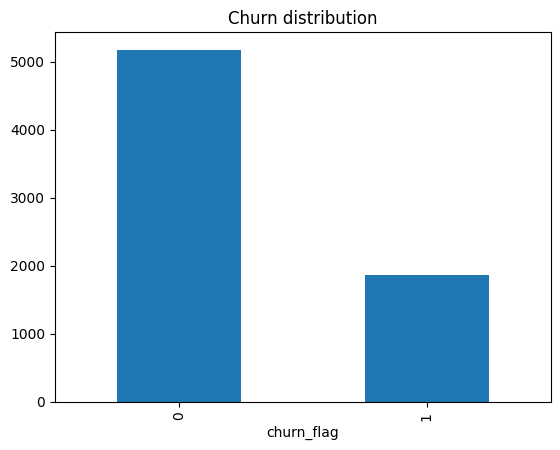

In [7]:
df["churn_flag"].value_counts().plot(kind="bar")
plt.title("Churn distribution")
plt.show()


In [8]:
df.groupby("churn_flag")["monthlycharges"].mean()


churn_flag
0    61.265124
1    74.441332
Name: monthlycharges, dtype: float64

In [9]:
pd.crosstab(df["contract"], df["churn_flag"], normalize="index")


churn_flag,0,1
contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


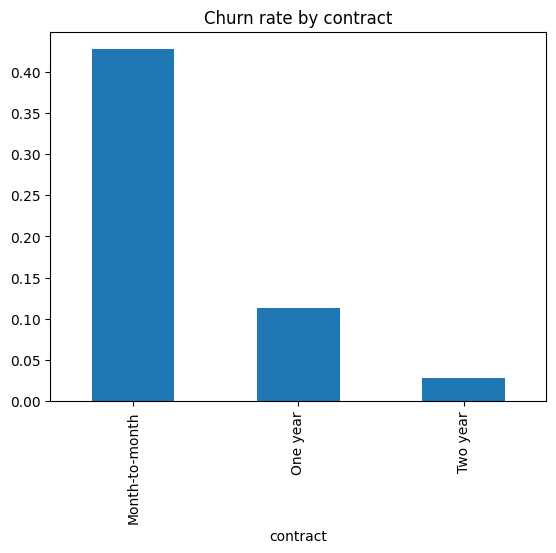

In [10]:
(pd.crosstab(df["contract"], df["churn_flag"], normalize="index")[1]
 .sort_values(ascending=False)
 .plot(kind="bar"))
plt.title("Churn rate by contract")
plt.show()


In [11]:
pd.crosstab(df["internetservice"], df["churn_flag"], normalize="index")


churn_flag,0,1
internetservice,,
DSL,0.810409,0.189591
Fiber optic,0.581072,0.418928
No,0.925950,0.074050
